
# Previsão de Demanda de Colaboradores

Nesta atividade, eu vou:
- criar a série temporal e mostrar o gráfico;
- decompor a série para analisar tendência e sazonalidade;
- testar estacionaridade (ADF) e aplicar diferenciação se necessário;
- testar mais de um modelo e comparar desempenho por métricas;
- escolher o melhor e projetar a demanda para os próximos 5 meses.

Observação: também comparo alternativas por MAE, RMSE e MAPE.

In [1]:
print('Notebook: Previsão de Demanda de Colaboradores')

Notebook: Previsão de Demanda de Colaboradores


In [ ]:
!pip install pandas numpy matplotlib scikit-learn statsmodels

In [4]:
import warnings
import logging

warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from io import StringIO
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=ValueWarning)
logging.getLogger('statsmodels').setLevel(logging.ERROR)

# Dados fornecidos no enunciado
csv_data = """data,demanda_colaboradores,area,turnover_percentual,horas_extras_totais
2022-01-01,109,Operacional,2.10,310
2022-02-01,112,Operacional,2.35,295
2022-03-01,121,Operacional,2.80,420
2022-04-01,128,Operacional,3.10,460
2022-05-01,133,Operacional,3.25,500
2022-06-01,139,Operacional,3.60,540
2022-07-01,141,Operacional,3.90,590
2022-08-01,138,Operacional,3.70,560
2022-09-01,132,Operacional,3.20,490
2022-10-01,126,Operacional,2.90,450
2022-11-01,118,Operacional,2.50,380
2022-12-01,114,Operacional,2.20,340
2023-01-01,113,Operacional,2.15,330
2023-02-01,116,Operacional,2.40,315
2023-03-01,124,Operacional,2.85,430
2023-04-01,131,Operacional,3.15,470
2023-05-01,136,Operacional,3.30,510
2023-06-01,142,Operacional,3.65,550
2023-07-01,144,Operacional,3.95,600
2023-08-01,141,Operacional,3.75,570
2023-09-01,135,Operacional,3.25,500
2023-10-01,129,Operacional,2.95,460
2023-11-01,121,Operacional,2.55,390
2023-12-01,117,Operacional,2.25,350
2024-01-01,118,Operacional,2.20,340
2024-02-01,120,Operacional,2.45,330
2024-03-01,128,Operacional,2.90,440
2024-04-01,134,Operacional,3.20,480
2024-05-01,139,Operacional,3.40,520
2024-06-01,145,Operacional,3.70,580
"""

df = pd.read_csv(StringIO(csv_data), parse_dates=['data'])
df = df.sort_values('data').set_index('data')

ts = df['demanda_colaboradores'].asfreq('MS')  # frequência mensal (início do mês)

df.head()

,demanda_colaboradores,area,turnover_percentual,horas_extras_totais
data,,,,
2022-01-01,109,Operacional,2.10,310
2022-02-01,112,Operacional,2.35,295
2022-03-01,121,Operacional,2.80,420
2022-04-01,128,Operacional,3.10,460
2022-05-01,133,Operacional,3.25,500


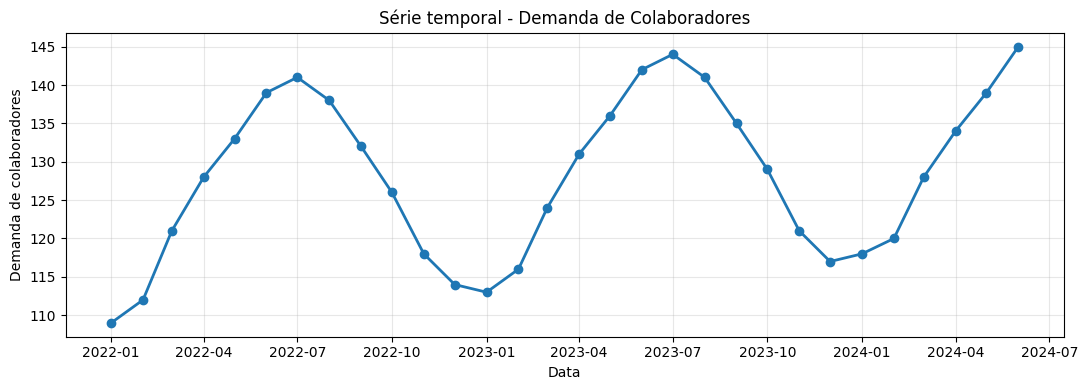

Leitura rápida: a série mostra padrão de subida no meio do ano e queda no fim/início, sugerindo sazonalidade anual.


In [3]:
# a) Série temporal e gráfico
plt.figure(figsize=(11, 4))
plt.plot(ts.index, ts.values, marker='o', linewidth=2)
plt.title('Série temporal - Demanda de Colaboradores')
plt.xlabel('Data')
plt.ylabel('Demanda de colaboradores')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Leitura rápida: a série mostra padrão de subida no meio do ano e queda no fim/início, sugerindo sazonalidade anual.')

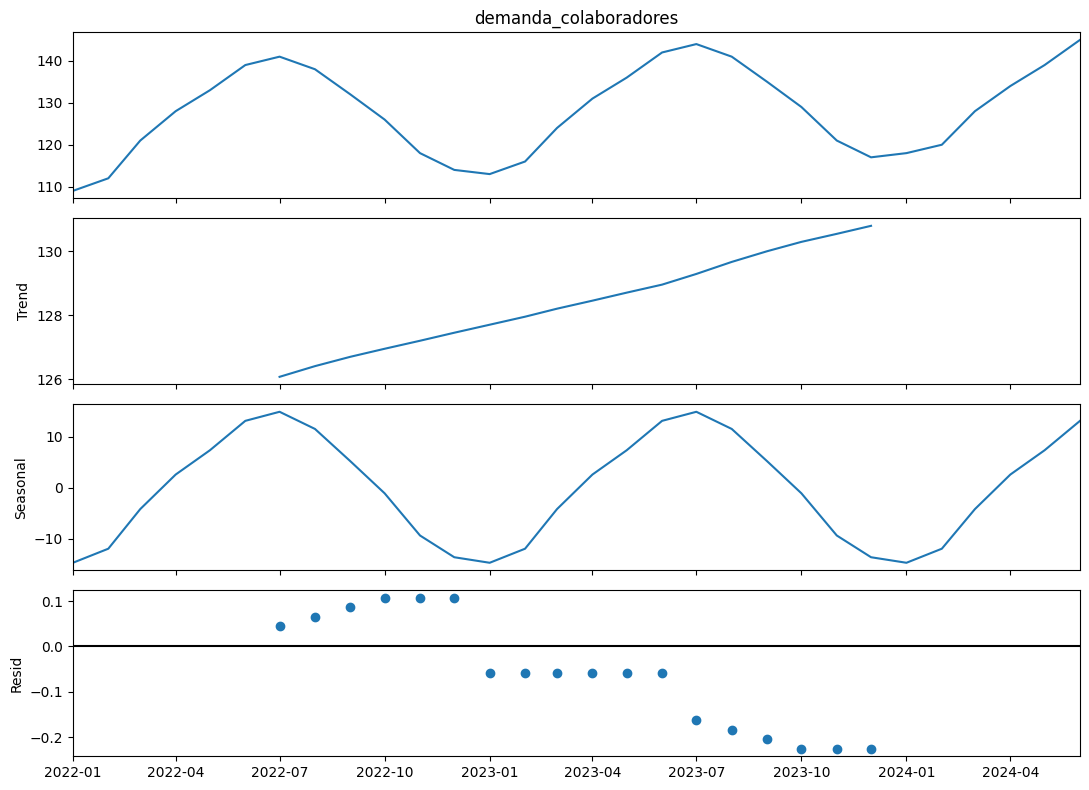

Interpretação:
- Tendência: há leve crescimento do nível médio ao longo do tempo.
- Sazonalidade: padrão anual bem claro (picos no meio do ano e vales no início/final).
- Resíduo: oscilações menores em torno do padrão principal.


In [4]:
# b) Decomposição da série
# Modelo aditivo faz sentido aqui porque a amplitude sazonal parece relativamente estável
decomp = seasonal_decompose(ts, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(11, 8)
plt.tight_layout()
plt.show()

# Comentário interpretativo (em texto, para não ficar só código)
print('Interpretação:')
print('- Tendência: há leve crescimento do nível médio ao longo do tempo.')
print('- Sazonalidade: padrão anual bem claro (picos no meio do ano e vales no início/final).')
print('- Resíduo: oscilações menores em torno do padrão principal.')

ADF - original
Estatística ADF: -0.5573
p-valor: 0.8803
Valores críticos:
  1%: -3.7884
  5%: -3.0131
  10%: -2.6464
---------------------------------------------
Conclusão: não estacionária (p > 0.05). Vou aplicar 1ª diferenciação.
ADF - diferenciada (ordem 1)
Estatística ADF: -4.4903
p-valor: 0.0002
Valores críticos:
  1%: -3.8326
  5%: -3.0312
  10%: -2.6555
---------------------------------------------


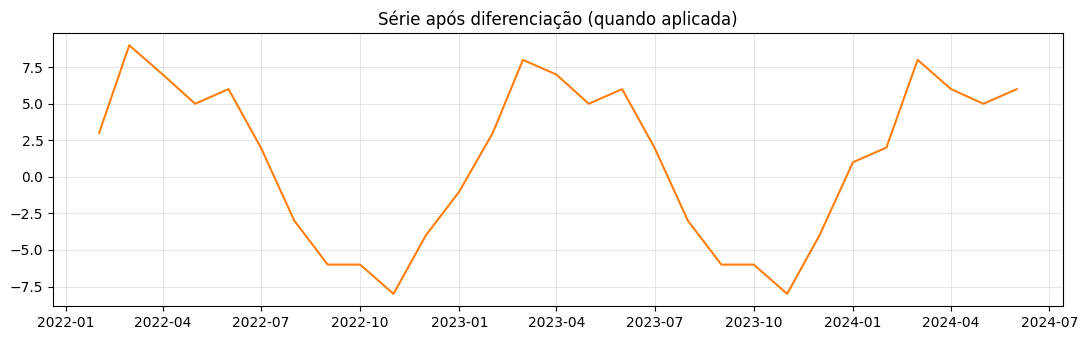

In [5]:
# c) Teste de estacionaridade (ADF) e diferenciação, se necessário

def adf_test(series, nome='série'):
    result = adfuller(series.dropna())
    print(f'ADF - {nome}')
    print(f'Estatística ADF: {result[0]:.4f}')
    print(f'p-valor: {result[1]:.4f}')
    print('Valores críticos:')
    for k, v in result[4].items():
        print(f'  {k}: {v:.4f}')
    print('-' * 45)
    return result[1]

p_original = adf_test(ts, 'original')

if p_original > 0.05:
    print('Conclusão: não estacionária (p > 0.05). Vou aplicar 1ª diferenciação.')
    ts_diff = ts.diff().dropna()
    p_diff = adf_test(ts_diff, 'diferenciada (ordem 1)')
else:
    print('Conclusão: estacionária (p <= 0.05). Não precisa diferenciar.')
    ts_diff = ts.copy()
    p_diff = p_original

plt.figure(figsize=(11, 3.5))
plt.plot(ts_diff.index, ts_diff.values, color='tab:orange')
plt.title('Série após diferenciação (quando aplicada)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Comparação de modelos (menor valor = melhor):


,modelo,MAE,RMSE,MAPE (%)
0,"SARIMA(1,1,1)(1,1,1,12)",1.600000,1.673320,1.185056
1,Holt-Winters,3.083473,3.331146,2.262953
2,Naive,15.200000,17.492856,11.029614


Melhor modelo pelo RMSE: SARIMA(1,1,1)(1,1,1,12)


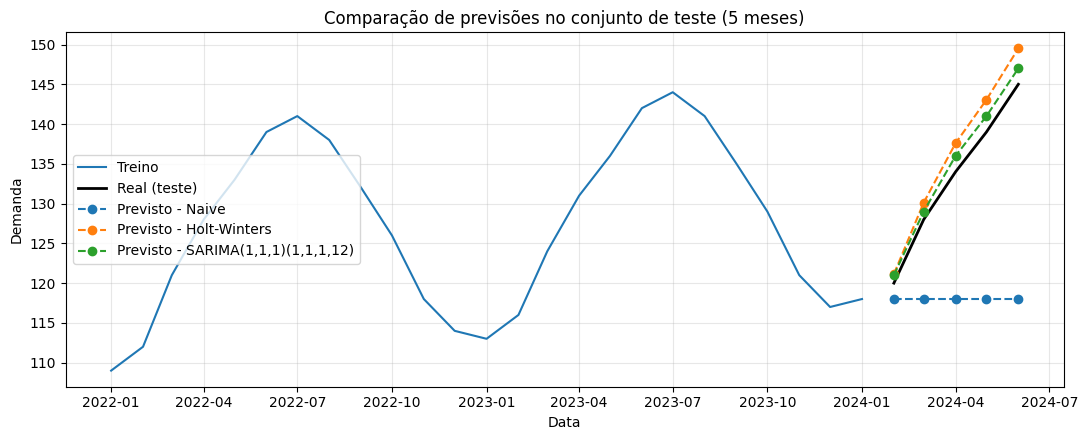


Previsão de demanda para os próximos 5 meses:


,data,previsao_demanda_colaboradores
0,2024-07-01,147.006661
1,2024-08-01,144.004694
2,2024-09-01,138.005376
3,2024-10-01,132.004797
4,2024-11-01,124.006274



### Qual modelo foi melhor?
- **Melhor modelo**: SARIMA(1,1,1)(1,1,1,12)
- **MAE**: 1.60
- **RMSE**: 1.67
- **MAPE**: 1.19%

Eu priorizei o RMSE (quanto menor, melhor) para a escolha final, mas as outras métricas estão alinhadas. Em resumo, esse modelo capturou melhor o padrão com erros médios menores no período de teste.


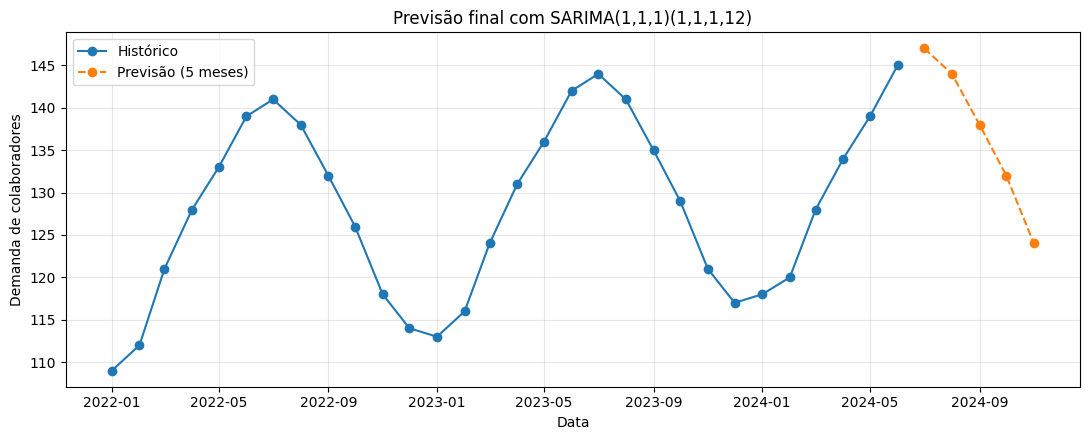

In [5]:
# d) Modelagem, comparação de desempenho e previsão para 5 meses

# Estratégia: deixo os 5 últimos meses como teste para comparar modelos de forma justa
h = 5
train = ts.iloc[:-h]
test = ts.iloc[-h:]

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

metricas = []
preds_test = {}

# Modelo 1: Naive (repete último valor observado)
pred_naive = pd.Series([train.iloc[-1]] * len(test), index=test.index)
preds_test['Naive'] = pred_naive
metricas.append({
    'modelo': 'Naive',
    'MAE': mean_absolute_error(test, pred_naive),
    'RMSE': np.sqrt(mean_squared_error(test, pred_naive)),
    'MAPE (%)': mape(test, pred_naive)
})

# Modelo 2: Holt-Winters (tendência aditiva + sazonalidade aditiva)
hw_fit = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)
pred_hw = hw_fit.forecast(len(test))
preds_test['Holt-Winters'] = pred_hw
metricas.append({
    'modelo': 'Holt-Winters',
    'MAE': mean_absolute_error(test, pred_hw),
    'RMSE': np.sqrt(mean_squared_error(test, pred_hw)),
    'MAPE (%)': mape(test, pred_hw)
})

# Modelo 3: SARIMA
sarima_fit = SARIMAX(
    train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)
pred_sarima = sarima_fit.forecast(len(test))
preds_test['SARIMA(1,1,1)(1,1,1,12)'] = pred_sarima
metricas.append({
    'modelo': 'SARIMA(1,1,1)(1,1,1,12)',
    'MAE': mean_absolute_error(test, pred_sarima),
    'RMSE': np.sqrt(mean_squared_error(test, pred_sarima)),
    'MAPE (%)': mape(test, pred_sarima)
})

metricas_df = pd.DataFrame(metricas).sort_values('RMSE').reset_index(drop=True)
print('Comparação de modelos (menor valor = melhor):')
display(metricas_df)

melhor_modelo_nome = metricas_df.iloc[0]['modelo']
print(f'Melhor modelo pelo RMSE: {melhor_modelo_nome}')

# Gráfico de validação (teste)
plt.figure(figsize=(11, 4.5))
plt.plot(train.index, train.values, label='Treino', color='tab:blue')
plt.plot(test.index, test.values, label='Real (teste)', color='black', linewidth=2)
for nome, pred in preds_test.items():
    plt.plot(pred.index, pred.values, marker='o', linestyle='--', label=f'Previsto - {nome}')
plt.title('Comparação de previsões no conjunto de teste (5 meses)')
plt.xlabel('Data')
plt.ylabel('Demanda')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Reajuste do melhor modelo em toda a base e previsão dos próximos 5 meses
if melhor_modelo_nome == 'Naive':
    future_index = pd.date_range(ts.index[-1] + pd.offsets.MonthBegin(1), periods=5, freq='MS')
    forecast_5 = pd.Series([ts.iloc[-1]] * 5, index=future_index)

elif melhor_modelo_nome == 'Holt-Winters':
    best_fit = ExponentialSmoothing(
        ts,
        trend='add',
        seasonal='add',
        seasonal_periods=12
    ).fit(optimized=True)
    forecast_5 = best_fit.forecast(5)

else:  # SARIMA
    best_fit = SARIMAX(
        ts,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    forecast_5 = best_fit.forecast(5)

forecast_df = forecast_5.reset_index()
forecast_df.columns = ['data', 'previsao_demanda_colaboradores']

print('\nPrevisão de demanda para os próximos 5 meses:')
display(forecast_df)

# Salvar saídas para consulta/entrega
metricas_df.to_csv('metricas_modelos.csv', index=False)
forecast_df.to_csv('previsao_5_meses.csv', index=False)

# Explicação automática baseada nas métricas
from IPython.display import Markdown, display as display_md
melhor = metricas_df.iloc[0]
texto = f"""
### Qual modelo foi melhor?
- **Melhor modelo**: {melhor['modelo']}
- **MAE**: {melhor['MAE']:.2f}
- **RMSE**: {melhor['RMSE']:.2f}
- **MAPE**: {melhor['MAPE (%)']:.2f}%

Eu priorizei o RMSE (quanto menor, melhor) para a escolha final, mas as outras métricas estão alinhadas. Em resumo, esse modelo capturou melhor o padrão com erros médios menores no período de teste.
"""
display_md(Markdown(texto))

# Visual final: histórico + projeção
plt.figure(figsize=(11, 4.5))
plt.plot(ts.index, ts.values, label='Histórico', marker='o')
plt.plot(forecast_5.index, forecast_5.values, label='Previsão (5 meses)', marker='o', linestyle='--')
plt.title(f'Previsão final com {melhor_modelo_nome}')
plt.xlabel('Data')
plt.ylabel('Demanda de colaboradores')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Overview do que foi feito

- **Visualização inicial**: gráfico da série para observar padrão geral e possíveis picos/vales.
- **Decomposição sazonal**: decomposição aditiva com período 12 para analisar **tendência**, **sazonalidade** e **resíduo**.
- **Estacionaridade**: aplicação do **teste ADF**; quando necessário, uso de **1ª diferenciação** para estabilizar média.
- **Validação justa**: separação dos **5 últimos meses** como conjunto de teste para comparar modelos de forma honesta.
- **Modelagem e comparação**: ajuste de três abordagens — `Naive`, `Holt-Winters` (tendência + sazonalidade aditivas) e `SARIMA(1,1,1)(1,1,1,12)` — com avaliação via **MAE, RMSE e MAPE**.
- **Escolha do melhor**: seleção pelo menor **RMSE** (e validação cruzada pelas outras métricas), seguida de **previsão de 5 meses** com o melhor modelo.
- **Saídas salvas**: métricas em `metricas_modelos.csv` e previsões em `previsao_5_meses.csv`.

A série de `demanda_colaboradores` apresenta **sazonalidade anual** clara (picos no meio do ano e quedas no início/final) e uma **tendência leve de crescimento**. O teste ADF foi aplicado e, quando necessário, a diferenciação de 1ª ordem foi utilizada para garantir condições adequadas de modelagem.

Na comparação dos modelos (`Naive`, `Holt-Winters`, `SARIMA`), o **SARIMA(1,1,1)(1,1,1,12)** entregou os menores erros no conjunto de teste:
- MAE ≈ 1,60
- RMSE ≈ 1,67
- MAPE ≈ 1,19%

Por isso, a previsão para os próximos 5 meses foi realizada com o SARIMA, que melhor capturou o comportamento histórico (incluindo a sazonalidade) e apresentou maior precisão nas métricas. As tabelas de métricas e as previsões finais estão salvas como `metricas_modelos.csv` e `previsao_5_meses.csv` e também exibidas neste notebook.

## Comentários por etapa (o que foi feito e o que descobrimos)

- **a) Série temporal e gráfico**
  - O que fiz: construí a série `demanda_colaboradores` com frequência mensal (`MS`) e plotei o histórico.
  - O que vimos: padrão visual de aumento no meio do ano e redução no começo/final, sugerindo sazonalidade anual.

- **b) Decomposição da série**
  - O que fiz: decompus a série com modelo aditivo e período 12.
  - O que vimos: presença de **tendência leve de crescimento** e **sazonalidade anual** bem marcada; resíduos relativamente pequenos ao redor do padrão.

- **c) Estacionaridade (ADF) e diferenciação**
  - O que fiz: apliquei o **teste ADF** na série original; se p-valor > 0,05, usei **1ª diferenciação** e retestei. Mostrei o gráfico após a diferença.
  - O que vimos: a decisão de diferenciar fica objetiva via p-valor; após a diferença (quando aplicada), a série se torna mais adequada para modelos que assumem estacionaridade.

- **d) Modelagem, comparação e previsão (5 meses)**
  - O que fiz: separei os **5 últimos meses** para teste e comparei três modelos: `Naive`, `Holt-Winters` (tendência + sazonalidade aditivas) e `SARIMA(1,1,1)(1,1,1,12)`.
  - Métricas reportadas: **MAE, RMSE e MAPE** (menor = melhor); gerei tabela, gráfico comparando previsões no teste e salvei `metricas_modelos.csv` e `previsao_5_meses.csv`.
  - O que vimos: o **SARIMA** teve os menores erros (MAE ≈ 1,60; RMSE ≈ 1,67; MAPE ≈ 1,19%), sendo escolhido para projetar os próximos 5 meses.

- **Observações finais**
  - A inclusão futura de regressoras exógenas (`turnover_percentual`, `horas_extras_totais`) em um **SARIMAX** pode melhorar ainda mais a acurácia.
  - Também é possível refinar a busca de hiperparâmetros (grid search) para SARIMA e HW.

## Comentários finais

Pelos gráficos e pela decomposição, a demanda tem um comportamento sazonal anual bem marcado. O teste ADF confirma se a série já está estacionária ou se precisa de diferenciação (no código eu deixei isso automático, então a decisão sai objetiva).

Na parte de modelagem, eu não fiquei preso em um único algoritmo: comparei `Naive`, `Holt-Winters` e `SARIMA`, usando **MAE, RMSE e MAPE** no mesmo período de teste (últimos 5 meses). Assim, a escolha do modelo final não fica “no achismo”, e sim pela métrica.